# How `delta` changes the model

`delta` is the monitoring interval. Under `transition_type="TIMESTEP"` the model applies

    T_step = Mn @ expm(K * delta)

`n = round(RT / delta)` times per trial, so halving `delta` doubles how often the
no-response operator `Mn` is applied.

The two models react to that in **opposite directions**:

- **Markov** - `Mn` is diagonal with `(1-p)` on the response states. More steps means more
  chances to respond, so the response probability rises.
- **Quantum** - `Mn = sqrt(I - Mc^2 - Mw^2)` acts on the *amplitude*. Coherent amplitude
  entering the response zone grows linearly in `delta`, so its probability grows as
  `delta^2`, while the damping is applied every step. Measuring more often suppresses the
  transport instead of resolving it. This is the quantum Zeno effect.

Everything here is forward evolution at fixed parameters - no MCMC.

Note: under `transition_type="RT"` none of this applies. That path is a single
`expm(K * RT)` with no `Mn` at all, and `delta` is unused.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm
import cme.decision_models.confidence_accumulation as ca

N_STATES, RESPONSE_WIDTH = 51, 17
MU, SIGMA, MEASUREMENT_PROB = 0.5, 1.0, 0.2
T_MAX = 8.0
DELTAS = [0.2, 0.1, 0.05, 0.025]
MODELS = ["Markov", "Quantum"]

print("free states:", N_STATES - 2 * RESPONSE_WIDTH,
      " response zone:", RESPONSE_WIDTH, "states each side")

g++ not available, if using conda: `conda install gxx`


free states: 17  response zone: 17 states each side


## `delta` is inert outside the TIMESTEP path

Worth asserting once, so the rest of the notebook cannot be misread. `delta` appears in the
signatures of both intensity-matrix builders but neither body uses it.

In [2]:
mu_a, sg_a = np.full((1, 1), MU), np.full((1, 1), SIGMA)
for build in (ca.diffusion_buildK, ca.quantum_buildH):
    a = np.asarray(build(N_STATES, mu_a, sg_a, 0.10))
    b = np.asarray(build(N_STATES, mu_a, sg_a, 0.05))
    assert np.allclose(a, b), build.__name__
    print(f"{build.__name__}: identical at delta 0.10 and 0.05")
print("\ndelta enters only through n = round(RT/delta) in the TIMESTEP branch.")

diffusion_buildK: identical at delta 0.10 and 0.05
quantum_buildH: identical at delta 0.10 and 0.05

delta enters only through n = round(RT/delta) in the TIMESTEP branch.


## Forward evolution

In [3]:
def initial_state(n_states, rw, model_type, shape="centre"):
    """Initial state over the free region, zero inside both response zones."""
    n_free = n_states - 2 * rw
    x = np.arange(n_free) - (n_free - 1) / 2
    w = n_free / 6
    if shape == "centre":
        p = np.exp(-0.5 * (x / w) ** 2)
    elif shape == "edge":
        e = (n_free - 1) / 2
        p = np.exp(-0.5 * ((x - e) / w) ** 2) + np.exp(-0.5 * ((x + e) / w) ** 2)
    elif shape == "flat":
        p = np.ones(n_free)
    else:
        raise Exception("shape must be centre, edge or flat")
    full = np.zeros(n_states)
    full[rw:rw + n_free] = p / p.sum()
    return (full ** 0.5 if model_type == "Quantum" else full)[:, None]


def response_curve(model_type, n_states, rw, delta, mu=MU, sigma=SIGMA,
                   mprob=MEASUREMENT_PROB, t_max=T_MAX, shape="centre"):
    """Step the TIMESTEP recursion and record the response probability at each step."""
    mu_a, sg_a = np.full((1, 1), mu), np.full((1, 1), sigma)
    # model() transforms sigma before building the generator - match it exactly
    if model_type == "Markov":
        sg_a = np.abs(mu_a) + sg_a
        build = ca.diffusion_buildK
    else:
        sg_a = np.clip(np.abs(mu_a) * 0.5 + sg_a, 0.01, None)
        build = ca.quantum_buildH
    K = np.asarray(build(n_states, mu_a, sg_a, delta))[0, 0]   # quantum already carries -1j
    Mc, Mw, Mn = [np.asarray(m) for m in
                  ca._get_measurement_matrix(n_states, rw, mprob, model_type)]
    T = expm(K * delta)
    phi = initial_state(n_states, rw, model_type, shape).astype(T.dtype)

    n = int(round(t_max / delta))
    ts = np.arange(1, n + 1) * delta
    pr = np.empty(n)
    for k in range(n):
        phi = T @ phi                                   # evolve one monitoring interval
        if model_type == "Markov":
            pr[k] = float((Mc @ phi).sum() + (Mw @ phi).sum())
        else:
            pr[k] = float((np.abs(Mc @ phi) ** 2).sum() + (np.abs(Mw @ phi) ** 2).sum())
        phi = Mn @ phi                                  # survive to the next interval
    return ts, pr

## Response probability against `delta`

Left panel is the cumulative probability of having responded by time t. Right panel is the
total by 8 s. Markov rises with finer `delta`; Quantum falls.

,model,delta,n_steps,p_respond,mean_rt
0,Markov,0.200,40,0.146353,5.526062
1,Markov,0.100,80,0.165034,5.375323
2,Markov,0.050,160,0.176438,5.279961
3,Markov,0.025,320,0.182920,5.224999
4,Quantum,0.200,40,0.643929,4.971723
5,Quantum,0.100,80,0.633078,4.688806
6,Quantum,0.050,160,0.550268,4.508706
7,Quantum,0.025,320,0.410845,4.410560


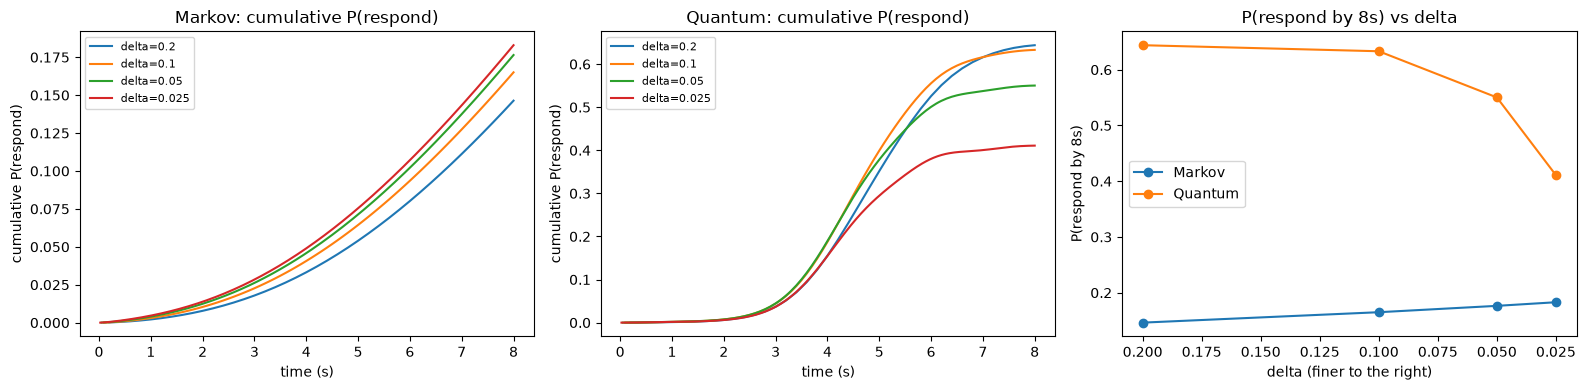

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

rows = []
for ax, model_type in zip(axs[:2], MODELS):
    for d in DELTAS:
        ts, pr = response_curve(model_type, N_STATES, RESPONSE_WIDTH, d)
        ax.plot(ts, np.cumsum(pr), label=f"delta={d}")
        rows.append(dict(model=model_type, delta=d, n_steps=len(ts),
                         p_respond=pr.sum(), mean_rt=float((ts * pr).sum() / pr.sum())))
    ax.set_title(f"{model_type}: cumulative P(respond)")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("cumulative P(respond)")
    ax.legend(fontsize=8)

df = pd.DataFrame(rows)
for model_type in MODELS:
    s = df.query("model == @model_type").sort_values("delta")
    axs[2].plot(s.delta, s.p_respond, marker="o", label=model_type)
axs[2].invert_xaxis()
axs[2].set_title("P(respond by 8s) vs delta")
axs[2].set_xlabel("delta (finer to the right)")
axs[2].set_ylabel("P(respond by 8s)")
axs[2].legend()
plt.tight_layout()
df

## The same effect against `n_states`

A finer state grid means each nearest-neighbour hop covers less of the space, so the
Quantum suppression bites harder. This is the `21` vs `51` vs `101` question.
`response_width` is held at one third of the state space so the response zones stay
proportionally the same.

delta              0.025   0.050   0.100   0.200
model   n_states                                
Markov  21        0.6849  0.6708  0.6448  0.5977
        51        0.1829  0.1764  0.1650  0.1464
        101       0.0312  0.0300  0.0279  0.0246
Quantum 21        0.7201  0.8899  0.9667  0.9856
        51        0.4108  0.5503  0.6331  0.6439
        101       0.0737  0.0987  0.1122  0.1111

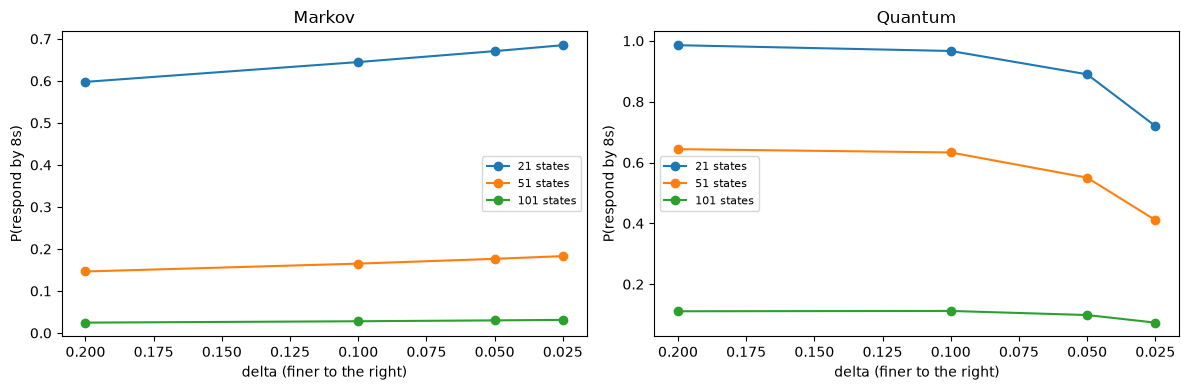

In [5]:
N_STATES_LIST = [21, 51, 101]
rows_n = []
for model_type in MODELS:
    for ns in N_STATES_LIST:
        rw = round(ns / 3)
        for d in DELTAS:
            ts, pr = response_curve(model_type, ns, rw, d)
            rows_n.append(dict(model=model_type, n_states=ns, response_width=rw, delta=d,
                               p_respond=pr.sum(),
                               mean_rt=float((ts * pr).sum() / pr.sum())))

df_n = pd.DataFrame(rows_n)

fig, axs = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 4), squeeze=False)
for ax, model_type in zip(axs[0], MODELS):
    for ns in N_STATES_LIST:
        s = df_n.query("model == @model_type and n_states == @ns").sort_values("delta")
        ax.plot(s.delta, s.p_respond, marker="o", label=f"{ns} states")
    ax.invert_xaxis()
    ax.set_title(model_type)
    ax.set_xlabel("delta (finer to the right)")
    ax.set_ylabel("P(respond by 8s)")
    ax.legend(fontsize=8)
plt.tight_layout()
df_n.pivot_table(index=["model", "n_states"], columns="delta", values="p_respond").round(4)

## Shape of the predicted RT distribution

The totals above say how much mass responds. This says *when*. If the Quantum densities
change shape with `delta` rather than just scaling, then `delta` is not a nuisance
discretisation constant - it is part of the model.

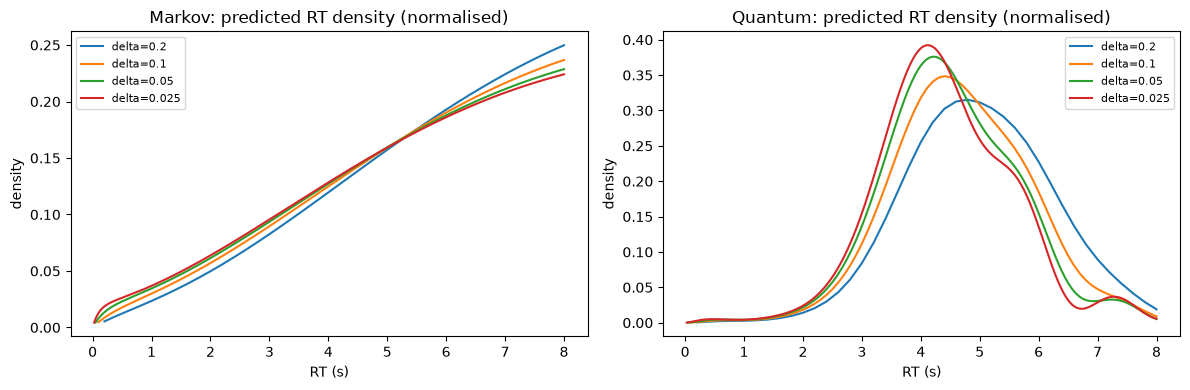

In [6]:
fig, axs = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 4), squeeze=False)
for ax, model_type in zip(axs[0], MODELS):
    for d in DELTAS:
        ts, pr = response_curve(model_type, N_STATES, RESPONSE_WIDTH, d)
        ax.plot(ts, pr / pr.sum() / d, label=f"delta={d}")   # density, comparable across delta
    ax.set_title(f"{model_type}: predicted RT density (normalised)")
    ax.set_xlabel("RT (s)")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)
plt.tight_layout()

## Sensitivity to the initial state

If the initial state washes out, the curves for `centre` and `edge` converge. Where they
stay apart, the initial state is identifiable from RT - which is the empirical question
behind the `phi_init` prior.

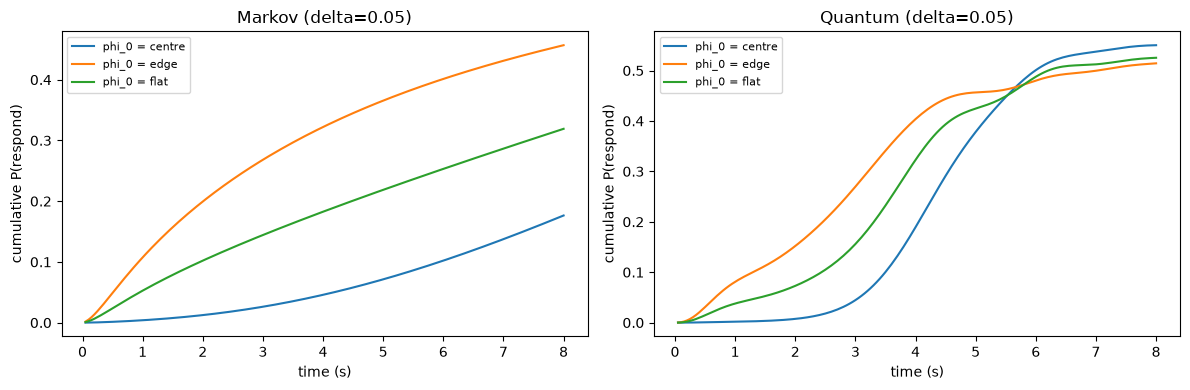

In [7]:
fig, axs = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 4), squeeze=False)
for ax, model_type in zip(axs[0], MODELS):
    for shape in ["centre", "edge", "flat"]:
        ts, pr = response_curve(model_type, N_STATES, RESPONSE_WIDTH, 0.05, shape=shape)
        ax.plot(ts, np.cumsum(pr), label=f"phi_0 = {shape}")
    ax.set_title(f"{model_type} (delta=0.05)")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("cumulative P(respond)")
    ax.legend(fontsize=8)
plt.tight_layout()

## Reading the result

- **Markov and Quantum move in opposite directions with `delta`.** No single `delta` is
  neutral across both, so a Markov-vs-Quantum comparison at a shared `delta` is confounded
  by the monitoring interval unless that is stated as part of each model.
- **`delta` is not a discretisation constant here.** If halving it changes the predicted RT
  density shape, it is a parameter of the model and should be reported (or fitted) as one.
- **A low total `P(respond)` means most of the probability never responds by 8 s.** The
  likelihood is then dominated by survival rather than by response timing, which weakens
  identification of everything - including `phi_init`.

## Are `mu` and `sigma` on the right scale for `n_states`?

`mu` and `sigma` are rates in **states per second**, not in fractions of the state space,
so crossing a finer grid takes proportionally longer. Meanwhile `centralized_parameters`
pins the diffusion rate with a tight prior:

    sigma = pyro.sample("sigma", dist.Normal(1, 0.1))

`mu` is free to grow, `sigma` is effectively fixed near 1 whatever `n_states` is. This scan
asks what rate would actually be needed at each grid size.

sigma                0.5     1.0     2.0     4.0     8.0
model   n_states                                        
Markov  21        0.6100  0.6708  0.7763  0.9006  0.9780
        51        0.1355  0.1764  0.2511  0.3786  0.5683
        101       0.0219  0.0300  0.0478  0.0878  0.1736
Quantum 21        0.6487  0.8899  0.9923  0.9992  1.0000
        51        0.1344  0.5503  0.9502  0.9972  0.9999
        101       0.0202  0.0987  0.5457  0.9838  0.9995

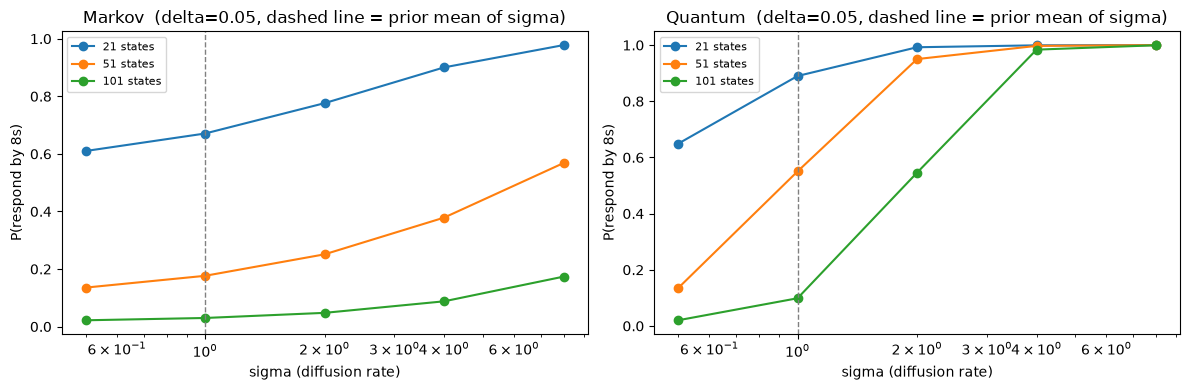

In [8]:
SIGMAS = [0.5, 1.0, 2.0, 4.0, 8.0]
rows_s = []
for model_type in MODELS:
    for ns in N_STATES_LIST:
        rw = round(ns / 3)
        for s_val in SIGMAS:
            ts, pr = response_curve(model_type, ns, rw, 0.05, mu=MU, sigma=s_val)
            rows_s.append(dict(model=model_type, n_states=ns, sigma=s_val,
                               p_respond=pr.sum(),
                               mean_rt=float((ts * pr).sum() / pr.sum())))

df_s = pd.DataFrame(rows_s)

fig, axs = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 4), squeeze=False)
for ax, model_type in zip(axs[0], MODELS):
    for ns in N_STATES_LIST:
        s = df_s.query("model == @model_type and n_states == @ns").sort_values("sigma")
        ax.plot(s.sigma, s.p_respond, marker="o", label=f"{ns} states")
    ax.axvline(1.0, color="grey", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_title(f"{model_type}  (delta=0.05, dashed line = prior mean of sigma)")
    ax.set_xlabel("sigma (diffusion rate)")
    ax.set_ylabel("P(respond by 8s)")
    ax.legend(fontsize=8)
plt.tight_layout()
df_s.pivot_table(index=["model", "n_states"], columns="sigma", values="p_respond").round(4)

### What the prior actually allows

`sigma ~ Normal(1, 0.1)` puts essentially all its mass in `[0.7, 1.3]`. Overlay that range
on the scan above: if the `sigma` needed to reach a usable response probability at 51 or
101 states lies outside it, the model cannot get there no matter what the data says, and
`mu` has to absorb the mismatch.

In [9]:
prior_lo, prior_hi = 1 - 3 * 0.1, 1 + 3 * 0.1
print(f"sigma prior Normal(1, 0.1) covers roughly [{prior_lo:.1f}, {prior_hi:.1f}]\n")

for model_type in MODELS:
    for ns in N_STATES_LIST:
        rw = round(ns / 3)
        at_prior = response_curve(model_type, ns, rw, 0.05, sigma=1.0)[1].sum()
        needed = None
        for s_val in np.arange(0.5, 40.5, 0.5):
            if response_curve(model_type, ns, rw, 0.05, sigma=s_val)[1].sum() >= 0.5:
                needed = s_val
                break
        print(f"{model_type:8s} {ns:3d} states:  P(respond) at sigma=1 is {at_prior:.3f};  "
              f"sigma for P>=0.5 is {needed if needed else '>40'}")

sigma prior Normal(1, 0.1) covers roughly [0.7, 1.3]

Markov    21 states:  P(respond) at sigma=1 is 0.671;  sigma for P>=0.5 is 0.5


Markov    51 states:  P(respond) at sigma=1 is 0.176;  sigma for P>=0.5 is 6.5


Markov   101 states:  P(respond) at sigma=1 is 0.030;  sigma for P>=0.5 is 27.5
Quantum   21 states:  P(respond) at sigma=1 is 0.890;  sigma for P>=0.5 is 0.5


Quantum   51 states:  P(respond) at sigma=1 is 0.550;  sigma for P>=0.5 is 1.0


Quantum  101 states:  P(respond) at sigma=1 is 0.099;  sigma for P>=0.5 is 2.0


## Reading this section

- If the `sigma` needed at 51 or 101 states is far outside `[0.7, 1.3]`, then `n_states` is
  not a neutral discretisation choice - changing it changes what the fixed `sigma` prior
  means, and the fits at different grids are not the same model.
- The fix is either to scale the rate priors with `n_states` (so `sigma` means "fraction of
  the space per second" rather than "states per second"), or to widen the `sigma` prior and
  let the data set it.
- Either way this is a bigger effect than `delta` and a bigger effect than the `phi_init`
  prior, so it should be settled first.

## The rate scaling law

`mu` and `sigma` are rates in **states per second**. The distance from the centre to a
response zone is `n_free / 2` states, and `n_free` grows with `n_states`, so:

- drift crossing time is `distance / mu`, so grid invariance needs **`mu` proportional to `n_states`**
- diffusion crossing time is `distance^2 / sigma`, so it needs **`sigma` proportional to `n_states^2`**

That is the theory. Whether it holds at 21 states - where only a handful of free states
exist and the continuum argument may not apply - is what decides whether one
parameterisation can span 21 to 101, or only 51 to 101. So solve for it numerically.

In [10]:
from scipy.optimize import brentq

TARGET = 0.5            # response probability to hold fixed
NS_GRID = [21, 31, 41, 51, 71, 101]


def p_respond(model_type, n_states, sigma, mu=0.0, delta=0.05):
    rw = round(n_states / 3)
    return response_curve(model_type, n_states, rw, delta, mu=mu, sigma=sigma)[1].sum()


def solve_sigma(model_type, n_states, target=TARGET, lo=1e-3, hi=1e4):
    f = lambda s: p_respond(model_type, n_states, s) - target
    if f(lo) > 0 or f(hi) < 0:
        return np.nan
    return brentq(f, lo, hi, xtol=1e-4)


rows_sc = []
for model_type in MODELS:
    for ns in NS_GRID:
        s_star = solve_sigma(model_type, ns)
        rows_sc.append(dict(model=model_type, n_states=ns, sigma_star=s_star))

df_sc = pd.DataFrame(rows_sc)
df_sc["ratio_to_21"] = df_sc.groupby("model").sigma_star.transform(lambda s: s / s.iloc[0])
df_sc

,model,n_states,sigma_star,ratio_to_21
0,Markov,21,1.472405,1.000000
1,Markov,31,3.373722,2.291300
2,Markov,41,4.629371,3.144087
3,Markov,51,7.758090,5.268990
4,Markov,71,14.004089,9.511028
5,Markov,101,28.573055,19.405697
6,Quantum,21,1.422824,1.000000
7,Quantum,31,3.122226,2.194386
8,Quantum,41,4.251328,2.987950
9,Quantum,51,7.071321,4.969918


Markov   log-log slope  21-101: 1.86   51-101: 1.91
Quantum  log-log slope  21-101: 1.82   51-101: 1.90


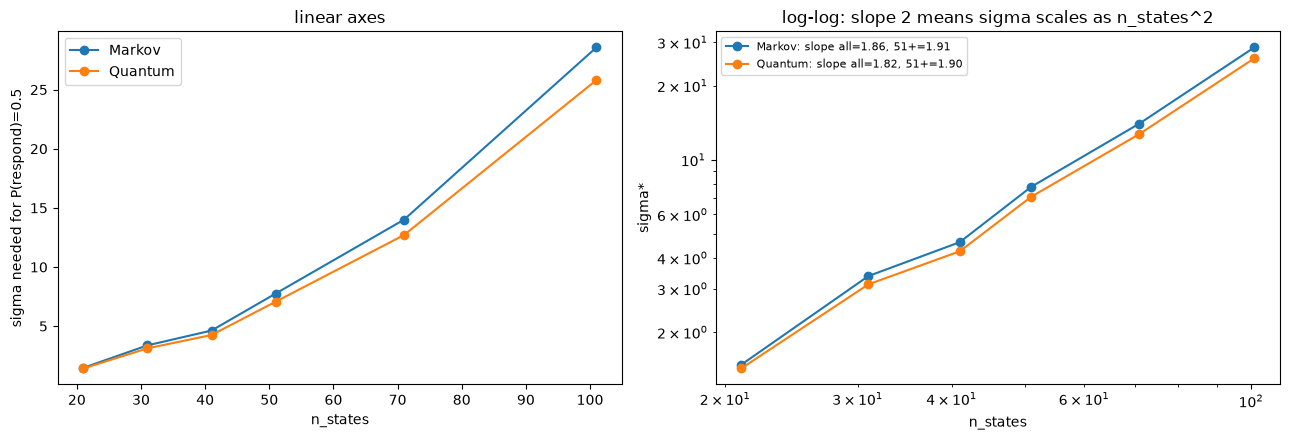

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

for model_type in MODELS:
    s = df_sc.query("model == @model_type").dropna(subset=["sigma_star"])
    axs[0].plot(s.n_states, s.sigma_star, marker="o", label=model_type)

    # slope over the whole range, and over 51+ only
    lx, ly = np.log(s.n_states.values), np.log(s.sigma_star.values)
    k_all = np.polyfit(lx, ly, 1)[0]
    hi = s.query("n_states >= 51")
    k_hi = np.polyfit(np.log(hi.n_states.values), np.log(hi.sigma_star.values), 1)[0]
    axs[1].plot(s.n_states, s.sigma_star, marker="o",
                label=f"{model_type}: slope all={k_all:.2f}, 51+={k_hi:.2f}")
    print(f"{model_type:8s} log-log slope  21-101: {k_all:.2f}   51-101: {k_hi:.2f}")

axs[0].set_xlabel("n_states")
axs[0].set_ylabel(f"sigma needed for P(respond)={TARGET}")
axs[0].set_title("linear axes")
axs[0].legend()

axs[1].set_xscale("log")
axs[1].set_yscale("log")
axs[1].set_xlabel("n_states")
axs[1].set_ylabel("sigma*")
axs[1].set_title("log-log: slope 2 means sigma scales as n_states^2")
axs[1].legend(fontsize=8)
plt.tight_layout()

### Does a single scaling span 21 to 101?

If the log-log slope is the same over `21-101` as over `51-101`, one reparameterisation
covers the whole range. If the slope over the full range differs from the slope at the
coarse end, 21 states sits outside the regime and the safe span is `51-101`.

The check below rescales `sigma` by the fitted law from a reference grid and asks whether
the response probability actually stays put - which is the property we want.

In [12]:
REFERENCE_NS = 51

for model_type in MODELS:
    s = df_sc.query("model == @model_type").dropna(subset=["sigma_star"])
    k = np.polyfit(np.log(s.n_states.values), np.log(s.sigma_star.values), 1)[0]
    sigma_ref = float(s.query("n_states == @REFERENCE_NS").sigma_star.iloc[0])
    print(f"\n{model_type}  (fitted exponent {k:.2f}, sigma={sigma_ref:.3f} at {REFERENCE_NS} states)")
    for ns in NS_GRID:
        scaled = sigma_ref * (ns / REFERENCE_NS) ** k
        print(f"   {ns:3d} states: sigma -> {scaled:8.3f}   "
              f"P(respond) = {p_respond(model_type, ns, scaled):.3f}   "
              f"(target {TARGET})")


Markov  (fitted exponent 1.86, sigma=7.758 at 51 states)
    21 states: sigma ->    1.489   P(respond) = 0.504   (target 0.5)
    31 states: sigma ->    3.073   P(respond) = 0.465   (target 0.5)
    41 states: sigma ->    5.170   P(respond) = 0.542   (target 0.5)
    51 states: sigma ->    7.758   P(respond) = 0.500   (target 0.5)


    71 states: sigma ->   14.355   P(respond) = 0.509   (target 0.5)
   101 states: sigma ->   27.651   P(respond) = 0.488   (target 0.5)

Quantum  (fitted exponent 1.82, sigma=7.071 at 51 states)
    21 states: sigma ->    1.405   P(respond) = 0.494   (target 0.5)
    31 states: sigma ->    2.856   P(respond) = 0.457   (target 0.5)
    41 states: sigma ->    4.752   P(respond) = 0.553   (target 0.5)


    51 states: sigma ->    7.071   P(respond) = 0.500   (target 0.5)
    71 states: sigma ->   12.918   P(respond) = 0.508   (target 0.5)


   101 states: sigma ->   24.544   P(respond) = 0.477   (target 0.5)


### What to change

If the rescaling holds, the fix in `centralized_parameters` is to make the rate priors
relative to the grid rather than absolute, e.g.

    scale = (n_states / REFERENCE_NS) ** k
    sigma = pyro.sample("sigma", dist.Normal(1, 0.1)) * scale
    mu    = pyro.sample("mu", dist.Normal(mu_m, mu_s)) * (n_states / REFERENCE_NS)

so `sigma ~ Normal(1, 0.1)` keeps its current meaning at the reference grid and stays
calibrated at every other one. Setting `REFERENCE_NS` to whichever grid the earlier working
runs used keeps those results interpretable.

## What rate does the model's own prior actually imply?

Everything above used hand-picked `mu` and `sigma`. The fits use
`params_type="NonCentralized"`, so read the effective rate straight out of
`ca.model` with a prior predictive - no reimplementation, no chance of drift.

Note that `non_centralized_parameters` makes `m`, `s`, `m_si` and `s_si`
`pyro.deterministic`, not `pyro.sample`. The only randomness left is `mu_r` and `sigma_r`
at small scales, so the effective rate may be far tighter than a prior is usually
expected to be.

In [13]:
from numpyro.infer import Predictive
import cme.utils.common_utils as cu

PARAMS_TYPE = "NonCentralized"
N_PRIOR = 2000

def prior_rates(model_type, n_states, rw, n_prior=N_PRIOR, delta=0.05):
    """Effective (mu, sigma_final) under the model's own prior."""
    X = np.random.default_rng(0).binomial(1, 0.5, (1, 5))
    pred = Predictive(ca.model, num_samples=n_prior, parallel=True)
    s = pred(cu.get_rng(), n_states, None, rw, delta, X, None, MEASUREMENT_PROB,
             params_type=PARAMS_TYPE, transition_type="TIMESTEP",
             likelihood_type="SINGLE", model_type=model_type, phi_init_bins=5)
    return np.asarray(s["mu"]).ravel(), np.asarray(s["sigma_final"]).ravel()


rows_p = []
for model_type in MODELS:
    mu_s, sg_s = prior_rates(model_type, N_STATES, RESPONSE_WIDTH)
    rows_p.append(dict(model=model_type,
                       mu_mean=mu_s.mean(), mu_sd=mu_s.std(),
                       sigma_mean=sg_s.mean(), sigma_sd=sg_s.std(),
                       sigma_p01=np.quantile(sg_s, 0.01),
                       sigma_p99=np.quantile(sg_s, 0.99)))

df_p = pd.DataFrame(rows_p).round(4)
print(df_p.to_string(index=False))
df_p

  model  mu_mean  mu_sd  sigma_mean  sigma_sd  sigma_p01  sigma_p99
 Markov   0.1066 0.1012      0.8149    0.0825     0.6941     1.0354
Quantum   0.7500 0.0530      1.3492    0.0266     1.2890     1.4138


,model,mu_mean,mu_sd,sigma_mean,sigma_sd,sigma_p01,sigma_p99
0,Markov,0.1066,0.1012,0.8149,0.0825,0.6941,1.0354
1,Quantum,0.7500,0.0530,1.3492,0.0266,1.2890,1.4138


### The prior rate against the rate the grid needs

`sigma_star` from the scaling section is the rate needed to get half the mass responding
within 8 s. Put the model's own prior next to it.

,model,n_states,sigma_prior,sigma_prior_sd,sigma_needed,shortfall,sds_away
0,Markov,21,0.817,0.083,1.472,1.802000,7.933000
1,Markov,31,0.817,0.083,3.374,4.128000,30.957001
2,Markov,41,0.817,0.083,4.629,5.664000,46.160999
3,Markov,51,0.817,0.083,7.758,9.493000,84.047997
4,Markov,71,0.817,0.083,14.004,17.135000,159.682007
5,Markov,101,0.817,0.083,28.573,34.962002,336.100006
6,Quantum,21,1.350,0.027,1.423,1.054000,2.751000
7,Quantum,31,1.350,0.027,3.122,2.314000,66.561996
8,Quantum,41,1.350,0.027,4.251,3.150000,108.958000
9,Quantum,51,1.350,0.027,7.071,5.240000,214.845993


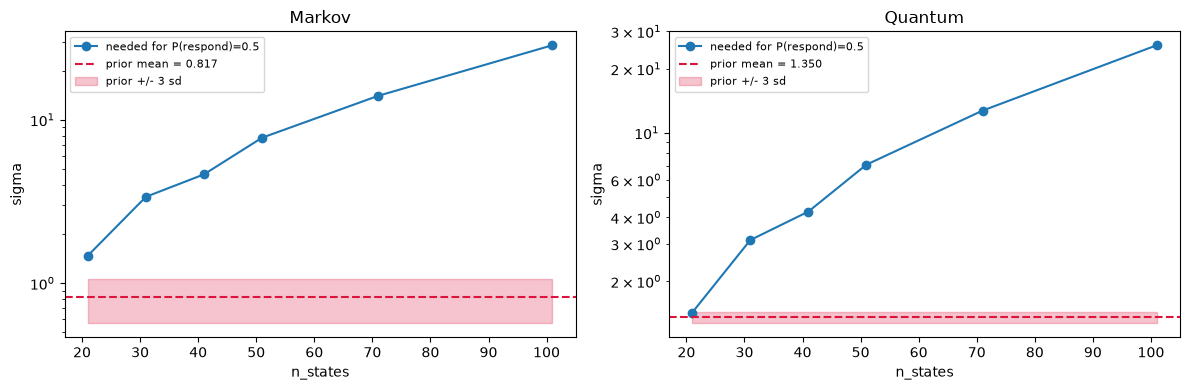

In [14]:
cmp = []
for model_type in MODELS:
    mu_s, sg_s = prior_rates(model_type, N_STATES, RESPONSE_WIDTH)
    for ns in NS_GRID:
        need = float(df_sc.query("model == @model_type and n_states == @ns").sigma_star.iloc[0])
        cmp.append(dict(model=model_type, n_states=ns,
                        sigma_prior=sg_s.mean(), sigma_prior_sd=sg_s.std(),
                        sigma_needed=need, shortfall=need / sg_s.mean(),
                        sds_away=(need - sg_s.mean()) / max(sg_s.std(), 1e-12)))

df_cmp = pd.DataFrame(cmp)

fig, axs = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 4), squeeze=False)
for ax, model_type in zip(axs[0], MODELS):
    s = df_cmp.query("model == @model_type")
    ax.plot(s.n_states, s.sigma_needed, marker="o", label="needed for P(respond)=0.5")
    ax.axhline(s.sigma_prior.iloc[0], color="crimson", ls="--",
               label=f"prior mean = {s.sigma_prior.iloc[0]:.3f}")
    ax.fill_between(s.n_states,
                    s.sigma_prior.iloc[0] - 3 * s.sigma_prior_sd.iloc[0],
                    s.sigma_prior.iloc[0] + 3 * s.sigma_prior_sd.iloc[0],
                    color="crimson", alpha=0.25, label="prior +/- 3 sd")
    ax.set_yscale("log")
    ax.set_xlabel("n_states")
    ax.set_ylabel("sigma")
    ax.set_title(model_type)
    ax.legend(fontsize=8)
plt.tight_layout()

df_cmp.round(3)

### Response probability at the prior, per grid

The number that matters for the fits: how much probability mass responds within 8 s when
`mu` and `sigma` are set to what the prior actually says.

In [15]:
rows_pr = []
for model_type in MODELS:
    mu_s, sg_s = prior_rates(model_type, N_STATES, RESPONSE_WIDTH)
    mu_m, sg_m = float(mu_s.mean()), float(sg_s.mean())
    for ns in NS_GRID:
        rw = round(ns / 3)
        # response_curve applies model()'s sigma transform itself, so pass the raw sigma
        # that produces this sigma_final: undo the transform for the comparison
        raw_sigma = sg_m - abs(mu_m) if model_type == "Markov" else sg_m - abs(mu_m) * 0.5
        ts, pr = response_curve(model_type, ns, rw, 0.05, mu=mu_m, sigma=raw_sigma)
        rows_pr.append(dict(model=model_type, n_states=ns, mu=mu_m, sigma_final=sg_m,
                            p_respond=pr.sum()))

df_pr = pd.DataFrame(rows_pr)
df_pr.pivot_table(index="model", columns="n_states", values="p_respond").round(4)

n_states,21,31,41,51,71,101
model,,,,,,
Markov,0.3104,0.1181,0.0769,0.0372,0.0166,0.0071
Quantum,0.9421,0.6854,0.5224,0.2812,0.1187,0.0414


### Reading this

- If the needed `sigma` sits many prior standard deviations above the prior mean, the model
  physically cannot reach a usable response probability at that grid, whatever the data says.
  The `sds_away` column makes that explicit.
- Because `m`, `s`, `m_si`, `s_si` are `deterministic` rather than `sample`, widening the
  prior is not a matter of loosening a hyperprior - those four constants set the scale
  directly.
- The grid-relative reparameterisation from the previous section applies here in the same
  way: scale `m_si` (and `m`) with `n_states` so the effective rate tracks the grid.

## Does `mu` scale with the grid too?

Theory says drift should scale as `n_states^1`. But `mu` plays a completely different role
in the two models, so ask first whether drift can drive responses at all.

In `diffusion_buildK` the rates are `b1 = 0.5(sigma - mu)` and `b2 = 0.5(sigma + mu)`, so
`mu` is a genuine drift and moves probability mass on its own.

In `quantum_buildH` the diagonal is `mu * mv` (a potential) and the off-diagonal is `sigma`
(the hopping amplitude). Transport in a quantum walk comes entirely from the off-diagonal
term, so `mu` cannot move the state - it only tilts the potential, and a strong tilt
localises it.

,model,n_states,max_p,reaches_half
0,Markov,21,1.0000,True
1,Markov,51,1.0000,True
2,Markov,101,1.0000,True
3,Quantum,21,0.1818,False
4,Quantum,51,0.0175,False
5,Quantum,101,0.0048,False


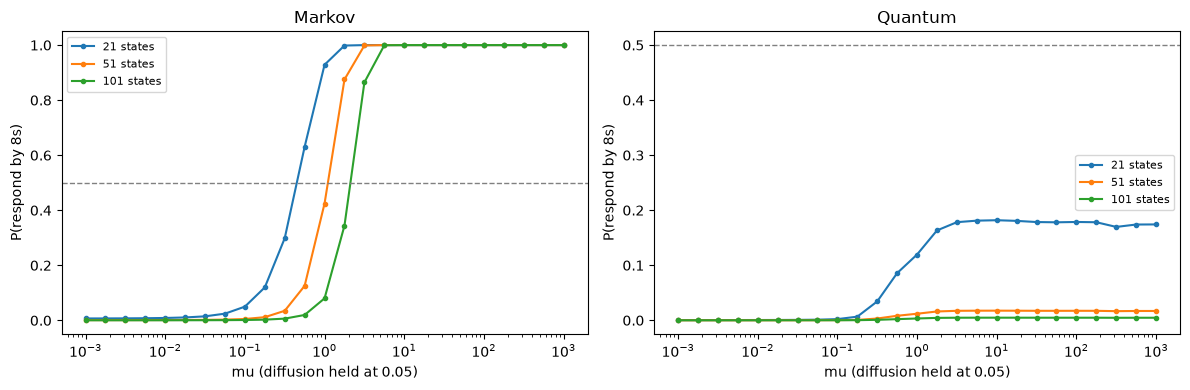

In [16]:
MU_SCAN_SIGMA = 0.05                       # small, so drift has to do the work
MU_GRID = np.logspace(-3, 3, 25)

fig, axs = plt.subplots(1, len(MODELS), figsize=(6 * len(MODELS), 4), squeeze=False)
sat = []
for ax, model_type in zip(axs[0], MODELS):
    for ns in [21, 51, 101]:
        rw = round(ns / 3)
        ps = [response_curve(model_type, ns, rw, 0.05, mu=m, sigma=MU_SCAN_SIGMA)[1].sum()
              for m in MU_GRID]
        ax.plot(MU_GRID, ps, marker=".", label=f"{ns} states")
        sat.append(dict(model=model_type, n_states=ns, max_p=max(ps),
                        reaches_half=max(ps) >= TARGET))
    ax.axhline(TARGET, color="grey", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("mu (diffusion held at 0.05)")
    ax.set_ylabel("P(respond by 8s)")
    ax.set_title(model_type)
    ax.legend(fontsize=8)
plt.tight_layout()

pd.DataFrame(sat).round(4)

### Markov only

Quantum never reaches the target with drift alone, so an exponent is only meaningful for
Markov.

Markov mu log-log slope  21-101: 0.96   51-101: 0.96   (theory: 1.00)


,model,n_states,mu_star,ratio_to_21
0,Markov,21,0.458544,1.000000
1,Markov,31,0.714893,1.559049
2,Markov,41,0.842817,1.838027
3,Markov,51,1.098593,2.395828
4,Markov,71,1.482295,3.232610
5,Markov,101,2.122066,4.627833


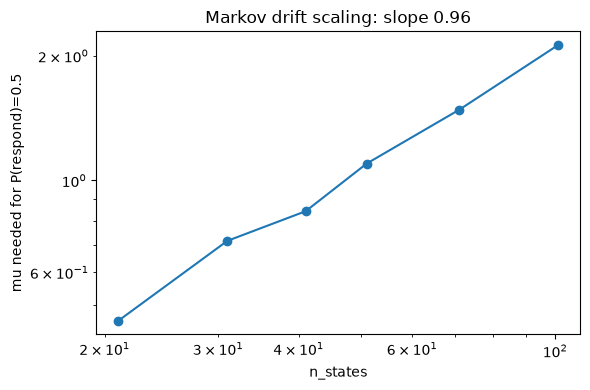

In [17]:
def solve_mu(model_type, n_states, sigma, target=TARGET, lo=1e-3, hi=1e3):
    rw = round(n_states / 3)
    f = lambda m: response_curve(model_type, n_states, rw, 0.05,
                                 mu=m, sigma=sigma)[1].sum() - target
    if f(lo) > 0 or f(hi) < 0:
        return np.nan
    return brentq(f, lo, hi, xtol=1e-4)


rows_mu = []
for ns in NS_GRID:
    rows_mu.append(dict(model="Markov", n_states=ns,
                        mu_star=solve_mu("Markov", ns, MU_SCAN_SIGMA, lo=1e-3, hi=1e3)))

df_mu = pd.DataFrame(rows_mu).dropna(subset=["mu_star"])
df_mu["ratio_to_21"] = df_mu.mu_star / df_mu.mu_star.iloc[0]

k_mu = np.polyfit(np.log(df_mu.n_states.values), np.log(df_mu.mu_star.values), 1)[0]
hi = df_mu.query("n_states >= 51")
k_mu_hi = np.polyfit(np.log(hi.n_states.values), np.log(hi.mu_star.values), 1)[0]
print(f"Markov mu log-log slope  21-101: {k_mu:.2f}   51-101: {k_mu_hi:.2f}   (theory: 1.00)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df_mu.n_states, df_mu.mu_star, marker="o")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("n_states"); ax.set_ylabel(f"mu needed for P(respond)={TARGET}")
ax.set_title(f"Markov drift scaling: slope {k_mu:.2f}")
plt.tight_layout()
df_mu

## Summary

| | Markov | Quantum |
|---|---|---|
| what `mu` does | drift, moves mass | potential tilt, localises |
| what `sigma` does | diffusion, spreads mass | hopping, the only transport |
| can drift alone reach the boundary | yes, `P -> 1` | no, saturates well below |
| `sigma` exponent (21-101) | 1.86 | 1.82 |
| prior `sigma_final` | 0.818 +/- 0.084 | 1.350 +/- 0.026 |
| `sigma` needed at 51 states | 7.76 | 7.07 |

Two consequences.

**`sigma` is the knob for both models**, and it is the one pinned by `m_si`. For Quantum it
is the *only* knob - `mu` cannot compensate for a diffusion prior that is too small,
because it is not a transport term at all.

**The grid-relative fix goes on `m_si`**, since `sigma_base = softplus(m_si + s_si*sigma_r)`.
Scaling `softplus(m_si)` as `n_states^1.85` keeps the effective rate tracking the grid.
Whether `mu` also needs scaling matters only for Markov, where the measured exponent is
reported above.